# Compare a trained RL policy against `BaselinePolicy`

Loads a saved `Actor` checkpoint, runs the **CRN-paired evaluation harness** from
`src/rl/eval.py` on a held-out 32-seed set, and inspects the result at three resolutions:

1. **Aggregate KPI table** — same numbers `--eval` logs to TensorBoard under `eval/*` keys.
2. **Per-seed detail** — paired uplift histogram, scatter on the 45° line, win-rate.
3. **Outlier inspection** — best / worst seeds and the episode parameters that drove them.

**Why CRN?** Each seed pair runs `BaselinePolicy` and the RL policy on bit-identical
`(world_seed, init_seed, capacity, balance, active subset, slot permutation)`. The world
trajectory is exactly the same between the two runs, so any difference is attributable
to the policy alone — world variance fully cancels. See
[docs/adr/0004-rl-training-env.md](../docs/adr/0004-rl-training-env.md) and
[docs/adr/0003-crn-demand-for-all-products.md](../docs/adr/0003-crn-demand-for-all-products.md).

**Reward identity.** The PPO reward each tick is `balance_after − balance_before`. Summed
across all 180 ticks this equals `aggregate_episode(...)['net_profit']`. So
`eval/rl_net_profit` and the episode return are the same currency.

In [1]:
%load_ext autoreload
%autoreload 2
import os
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.rl.agents.ppo import Actor
from src.rl.configs.default import RLConfig
from src.rl.encoders import observation_dim, action_dim
from src.rl.eval import build_eval_seeds, evaluate
from src.sim.policy import BaselinePolicy
from src.sim.scenario import StoreTemplate, load_catalog

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (9, 4)

## 1. Pick a checkpoint and reconstruct the training config

`Actor` requires the same `(obs_dim, act_dim)` it was trained with. Both are derived from `RLConfig.K_active`, so as long as you set `K_active` to the value used during training, the `state_dict` load succeeds.

If you trained with a non-default `RLConfig`, pass the same overrides here (e.g. `RLConfig(K_active=8, K_catalog=200)`).

In [2]:
RUNS_ROOT = Path('runs')
EXPERIMENT = 'fashion_run'

ckpts = sorted((RUNS_ROOT / EXPERIMENT / 'checkpoints').glob('actor_step*.pt'))
assert ckpts, f'No checkpoints found under {RUNS_ROOT / EXPERIMENT / "checkpoints"}. Run training first.'

CHECKPOINT_PATH = ckpts[-1]  # default: most recent checkpoint
print(f'Available checkpoints under {RUNS_ROOT / EXPERIMENT}:')
for p in ckpts:
    marker = ' ← selected' if p == CHECKPOINT_PATH else ''
    print(f'  {p.name}{marker}')

# RLConfig defaults — change here if you trained with overrides.
config = RLConfig()
print(f'\nUsing RLConfig: K_active={config.K_active}, K_catalog={config.K_catalog}, '
      f'episode_length={config.episode_length}, n_eval_seeds={config.n_eval_seeds}')

Available checkpoints under runs/fashion_run:
  actor_step0000000000.pt
  actor_step0000000001.pt
  actor_step0000000002.pt
  actor_step0000000003.pt
  actor_step0000000004.pt
  actor_step0000000005.pt
  actor_step0000000006.pt
  actor_step0000000007.pt
  actor_step0000000008.pt
  actor_step0000000009.pt
  actor_step0000000010.pt
  actor_step0000000011.pt
  actor_step0000000012.pt
  actor_step0000000013.pt
  actor_step0000000014.pt
  actor_step0000000015.pt
  actor_step0000000016.pt
  actor_step0000000017.pt
  actor_step0000000018.pt
  actor_step0001000000.pt ← selected

Using RLConfig: K_active=5, K_catalog=100, episode_length=180, n_eval_seeds=32


## 2. Build the catalog and base store template

Must match what `train.py` used. Resolution order is the same as the training driver:

1. Explicit world cache (`WORLD_CACHE_PATH` below) if it exists.
2. Auto-lookup at `data/worlds/<WORLD_ARCHETYPE>/world.json`.
3. Synthetic catalog of size `K_catalog` (no LLM required).

If you change the catalog here vs training, the comparison still runs but the result is no longer comparable to the TensorBoard `eval/*` curves — episode dynamics depend on the catalog.

In [3]:
WORLD_CACHE_PATH: Path | None = None        # e.g. Path('data/worlds/fashion_retail_1000/world.json')
WORLD_ARCHETYPE = 'rl_train'


def _build_synthetic_catalog(cfg):
    items = [
        {
            'name': f'Product {i}',
            'category': 'General',
            'related_products': [],
            'base_price': float(10 + (i % 30)),
            'unit_cost': float(4 + (i % 10)),
            'seasonality': 'all_season',
        }
        for i in range(cfg.K_catalog)
    ]
    catalog = load_catalog(items)
    template = StoreTemplate(
        id='rl_train_default', region='US',
        capacity=200, init_balance=20_000.0, init_stock_pct=0.0,
        delivery_lag=cfg.delivery_lag, holding_rate=cfg.holding_rate,
        order_fee=cfg.order_fee, init_active_count=cfg.K_active,
    )
    return catalog, template, 'synthetic'


def _load_world_catalog(cache_path, cfg):
    from src.llm.world_builder import World
    world = World.from_json(cache_path)
    catalog = world.catalog
    if world.store_templates:
        key = next(iter(world.store_templates))
        t = world.store_templates[key]
        template = StoreTemplate(
            id=t.id, region=t.region,
            capacity=200, init_balance=20_000.0, init_stock_pct=0.0,
            delivery_lag=cfg.delivery_lag, holding_rate=cfg.holding_rate,
            order_fee=cfg.order_fee, init_active_count=cfg.K_active,
        )
    else:
        template = StoreTemplate(
            id='rl_train_default', region='US',
            capacity=200, init_balance=20_000.0, init_stock_pct=0.0,
            delivery_lag=cfg.delivery_lag, holding_rate=cfg.holding_rate,
            order_fee=cfg.order_fee, init_active_count=cfg.K_active,
        )
    return catalog, template, f'world cache @ {cache_path}'


if WORLD_CACHE_PATH and WORLD_CACHE_PATH.exists():
    catalog, base_template, source = _load_world_catalog(WORLD_CACHE_PATH, config)
else:
    auto = Path('data/worlds') / WORLD_ARCHETYPE / 'world.json'
    if auto.exists():
        catalog, base_template, source = _load_world_catalog(auto, config)
    else:
        catalog, base_template, source = _build_synthetic_catalog(config)

print(f'Catalog source: {source}')
print(f'Catalog size : {len(catalog)} (must be >= K_active = {config.K_active})')
print(f'Template     : id={base_template.id}, region={base_template.region}, '
      f'delivery_lag={base_template.delivery_lag}, holding_rate={base_template.holding_rate}, '
      f'order_fee={base_template.order_fee}')

Catalog source: synthetic
Catalog size : 100 (must be >= K_active = 5)
Template     : id=rl_train_default, region=US, delivery_lag=3, holding_rate=0.01, order_fee=50.0


## 3. Load the actor

`Actor.get_distribution(obs)` returns a `Normal(mean = tanh(net(obs)), std = exp(log_std))`. For evaluation we use the **deterministic** action — `dist.mean`, which is already squashed into `(-1, 1)` — to remove sampling noise from the comparison. Switching to stochastic sampling is one-line if you want to see the policy under exploration noise.

In [4]:
obs_dim = observation_dim(config.K_active)
act_dim = action_dim(config.K_active)
print(f'obs_dim = {obs_dim}, act_dim = {act_dim}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
actor = Actor(obs_dim, act_dim).to(device)
actor.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
actor.eval()

DETERMINISTIC = True  # set False to use stochastic samples

def rl_policy_fn(obs_np):
    obs_t = torch.tensor(obs_np, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        if DETERMINISTIC:
            action_t = actor.get_distribution(obs_t).mean
        else:
            action_t, _, _ = actor.get_action_and_log_prob(obs_t)
    return action_t.squeeze(0).cpu().numpy().astype(np.float32)


def baseline_factory():
    """Fresh BaselinePolicy each seed so policy_rng is reset."""
    return BaselinePolicy()

print(f'\nLoaded checkpoint: {CHECKPOINT_PATH}')
print(f'Deterministic eval: {DETERMINISTIC}')

obs_dim = 69, act_dim = 10

Loaded checkpoint: runs/fashion_run/checkpoints/actor_step0001000000.pt
Deterministic eval: True


## 4. Build the held-out CRN eval set

Seeds come from `[config.eval_seed_offset, config.eval_seed_offset + n_eval_seeds)` — well above the training seed space (default offset `10_000_000`). Two calls with the same `(catalog, base_template, config)` return identical specs — the function is pure.

In [5]:
eval_specs = build_eval_seeds(catalog, base_template, config)
print(f'Built {len(eval_specs)} eval specs (seeds {config.eval_seed_offset}..{config.eval_seed_offset + len(eval_specs) - 1}).')

# Peek at the first spec for orientation.
spec0 = eval_specs[0]
print(f'\nSpec 0:')
print(f'  world_seed       = {spec0.scenario.world_seed}')
print(f'  capacity         = {spec0.scenario.stores[0].template.capacity}')
print(f'  init_balance     = {spec0.scenario.stores[0].template.init_balance:.2f}')
print(f'  active_subset    = {spec0.active_subset}')
print(f'  slot_permutation = {spec0.slot_permutation}')

Built 32 eval specs (seeds 10000000..10000031).

Spec 0:
  world_seed       = 1345003908
  capacity         = 340
  init_balance     = 39345.78
  active_subset    = ('P0019', 'P0039', 'P0049', 'P0089', 'P0094')
  slot_permutation = (4, 3, 0, 2, 1)


## 5. Aggregate paired metrics

Identical to what training logs under `eval/*` keys. Each `evaluate(...)` call runs every seed twice — once with the RL policy, once with a fresh `BaselinePolicy` — and aggregates the per-seed metric dicts.

In [6]:
agg = evaluate(
    rl_policy_fn=rl_policy_fn,
    baseline_policy_factory=baseline_factory,
    eval_specs=eval_specs,
    config=config,
)

kpi_names = ['return', 'service_level', 'stockout_rate', 'inventory_turnover',
             'mean_price_pct_of_msrp', 'revenue', 'net_profit']
agg_table = pd.DataFrame([
    {'kpi': k,
     'RL': agg.get(f'eval/rl_{k}', float('nan')),
     'Baseline': agg.get(f'eval/baseline_{k}', float('nan'))}
    for k in kpi_names
]).set_index('kpi')
agg_table['Δ (RL − Base)'] = agg_table['RL'] - agg_table['Baseline']

print(f'paired_uplift (mean over {len(eval_specs)} seeds): {agg["eval/paired_uplift"]:.2f}')
print(f'win_rate                                          : {agg["eval/win_rate"]:.2%}')
agg_table

paired_uplift (mean over 32 seeds): 74529.28
win_rate                                          : 100.00%


,RL,Baseline,Δ (RL − Base)
kpi,,,
return,90303.379982,15774.097188,74529.282795
service_level,0.929437,0.153838,0.775599
stockout_rate,0.205035,0.909028,-0.703993
inventory_turnover,453.494287,1357.368116,-903.873829
mean_price_pct_of_msrp,1.286770,1.081371,0.205399
revenue,193620.051545,32806.938438,160813.113107
net_profit,90303.379982,15774.097188,74529.282795


## 6. Per-seed detail

`evaluate(...)` returns aggregates, not per-seed values. To recover per-seed metrics we call `evaluate(...)` once per spec (with a one-element list). The arithmetic is identical to a single iteration of the full call, so this is exact — just a bit slower than batching.

In [8]:
rows = []
for i, spec in enumerate(eval_specs):
    one = evaluate(
        rl_policy_fn=rl_policy_fn,
        baseline_policy_factory=baseline_factory,
        eval_specs=[spec],
        config=config,
    )
    rows.append({
        'seed_idx': i,
        'episode_seed': config.eval_seed_offset + i,
        'capacity': spec.scenario.stores[0].template.capacity,
        'init_balance': spec.scenario.stores[0].template.init_balance,
        'rl_return': one['eval/rl_return'],
        'baseline_return': one['eval/baseline_return'],
        'uplift': one['eval/paired_uplift'],
        'rl_service_level': one['eval/rl_service_level'],
        'baseline_service_level': one['eval/baseline_service_level'],
        'rl_stockout_rate': one['eval/rl_stockout_rate'],
        'baseline_stockout_rate': one['eval/baseline_stockout_rate'],
        'rl_inventory_turnover': one['eval/rl_inventory_turnover'],
        'baseline_inventory_turnover': one['eval/baseline_inventory_turnover'],
        'rl_mean_price_pct_of_msrp': one['eval/rl_mean_price_pct_of_msrp'],
        'baseline_mean_price_pct_of_msrp': one['eval/baseline_mean_price_pct_of_msrp'],
        'rl_revenue': one['eval/rl_revenue'],
        'baseline_revenue': one['eval/baseline_revenue'],
    })

per_seed = pd.DataFrame(rows)
per_seed.head(10)

,seed_idx,episode_seed,capacity,init_balance,rl_return,baseline_return,uplift,rl_service_level,baseline_service_level,rl_stockout_rate,baseline_stockout_rate,rl_inventory_turnover,baseline_inventory_turnover,rl_mean_price_pct_of_msrp,baseline_mean_price_pct_of_msrp,rl_revenue,baseline_revenue
0,0,10000000,340,39345.781828,86270.819923,16824.23,69446.589923,0.966082,0.178256,0.098889,0.905556,176.385799,1615.000000,1.266903,1.076027,218314.279923,40878.24
1,1,10000001,254,37136.212619,113016.929102,20577.69,92439.239102,0.951223,0.161431,0.164444,0.907778,335.107508,1439.000000,1.282810,1.078338,219552.819102,39057.92
2,2,10000002,173,29704.723730,95086.921781,11470.01,83616.911781,0.839817,0.104381,0.434444,0.962222,1648.203593,915.000000,1.293459,1.085567,191869.111781,24307.05
3,3,10000003,162,33009.001458,100858.007578,11685.75,89172.257578,0.900628,0.107876,0.271111,0.957778,741.428571,930.000000,1.288607,1.087444,185543.327578,22573.70
4,4,10000004,292,21826.124094,105345.796145,24258.90,81086.896145,0.933395,0.188348,0.202222,0.871111,203.268047,1637.180910,1.291717,1.080900,207826.346145,43169.80
5,5,10000005,198,36499.893239,57268.502882,8641.06,48627.442882,0.876944,0.128756,0.324444,0.930000,681.821671,1127.000000,1.273599,1.085778,150386.872882,22412.10
6,6,10000006,259,15520.834021,71378.358620,14358.02,57020.338620,0.889449,0.160678,0.274444,0.905556,490.778880,1431.000000,1.295254,1.079160,179485.588620,34338.71
7,7,10000007,272,18983.585940,83278.159387,16225.29,67052.869387,0.946608,0.174237,0.157778,0.888889,272.792363,1542.000000,1.292563,1.081152,198382.109387,37494.57
8,8,10000008,317,33181.145616,130155.835347,30291.41,99864.425347,0.955900,0.200638,0.121111,0.882222,215.914328,1823.000000,1.287837,1.075344,236429.145347,51589.61
9,9,10000009,366,15906.924723,96133.496024,21422.16,74711.336024,0.966749,0.193603,0.098889,0.868889,150.921228,1512.106299,1.297138,1.077578,206201.996024,42170.11


## 7. Paired-uplift distribution

Histogram of per-seed `(RL − Baseline)` net profit. A symmetric distribution centred near zero means the policy hasn't really learned; a clean right-shift away from zero is what you want. The dashed vertical lines mark zero (no improvement) and the mean uplift.

Per-seed uplift summary (n = 32):
  mean   = +74607.60  (stderr ±3761.60)
  median = +72402.96
  min    = +36682.37
  max    = +125383.76
  win-rate (uplift ≥ 0) = 100.00%


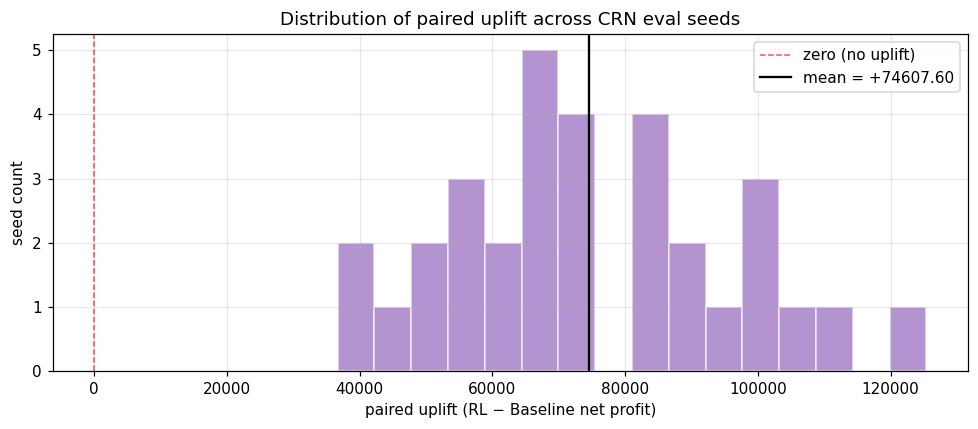

In [9]:
uplift = per_seed['uplift'].to_numpy()

mean_u = uplift.mean()
median_u = np.median(uplift)
win_rate = (uplift >= 0).mean()
stderr = uplift.std(ddof=1) / np.sqrt(len(uplift)) if len(uplift) > 1 else float('nan')

print(f'Per-seed uplift summary (n = {len(uplift)}):')
print(f'  mean   = {mean_u:+.2f}  (stderr ±{stderr:.2f})')
print(f'  median = {median_u:+.2f}')
print(f'  min    = {uplift.min():+.2f}')
print(f'  max    = {uplift.max():+.2f}')
print(f'  win-rate (uplift ≥ 0) = {win_rate:.2%}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(uplift, bins=min(20, max(5, len(uplift) // 2)), color='tab:purple', alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='zero (no uplift)')
ax.axvline(mean_u, color='black', linestyle='-', linewidth=1.5, label=f'mean = {mean_u:+.2f}')
ax.set_xlabel('paired uplift (RL − Baseline net profit)')
ax.set_ylabel('seed count')
ax.set_title('Distribution of paired uplift across CRN eval seeds')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Per-seed scatter — RL vs Baseline

One dot per seed; x is baseline net profit, y is RL net profit. Points **above** the 45° line are seeds where RL won, **below** are seeds where baseline won. Tight clustering along the line means the policy mostly matches baseline; clear vertical separation above the line is what you want.

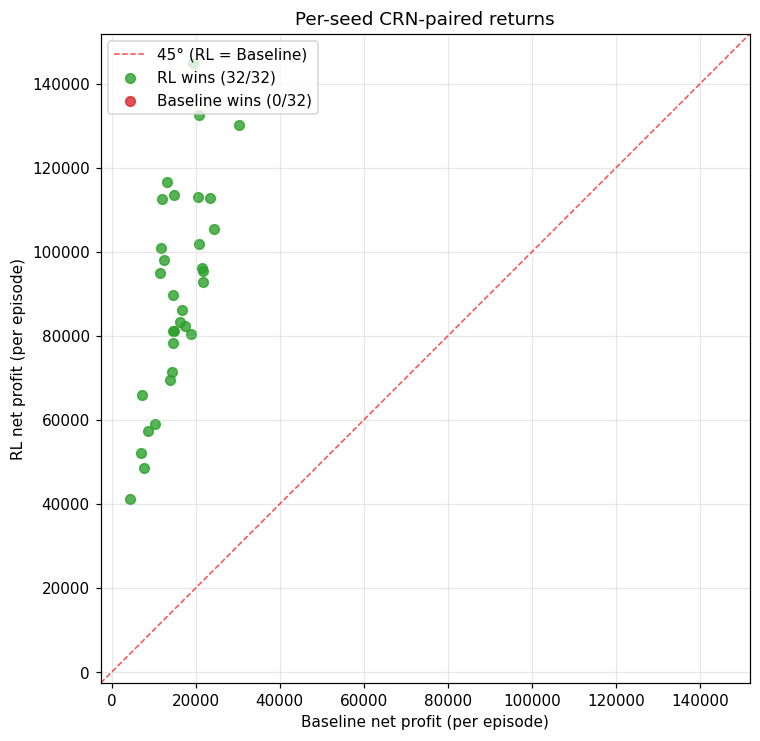

In [10]:
x = per_seed['baseline_return'].to_numpy()
y = per_seed['rl_return'].to_numpy()
wins = y >= x

lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
pad = 0.05 * max(1.0, hi - lo)
lim = (lo - pad, hi + pad)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(lim, lim, color='red', linestyle='--', linewidth=1, alpha=0.7, label='45° (RL = Baseline)')
ax.scatter(x[wins], y[wins], color='tab:green', s=40, alpha=0.8, label=f'RL wins ({wins.sum()}/{len(wins)})')
ax.scatter(x[~wins], y[~wins], color='tab:red', s=40, alpha=0.8, label=f'Baseline wins ({(~wins).sum()}/{len(wins)})')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Baseline net profit (per episode)')
ax.set_ylabel('RL net profit (per episode)')
ax.set_title('Per-seed CRN-paired returns')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 9. Business KPI side-by-side

How is the policy winning (or losing)? Each pair of bars shows the mean across the eval seeds. Lower stockout rate + higher service level + comparable pricing → the policy ordered better; lower pricing + higher revenue → the policy discounted strategically. A win that comes purely from heavier discounting (lower mean_price_pct_of_msrp) without matching the baseline's service level is fragile.

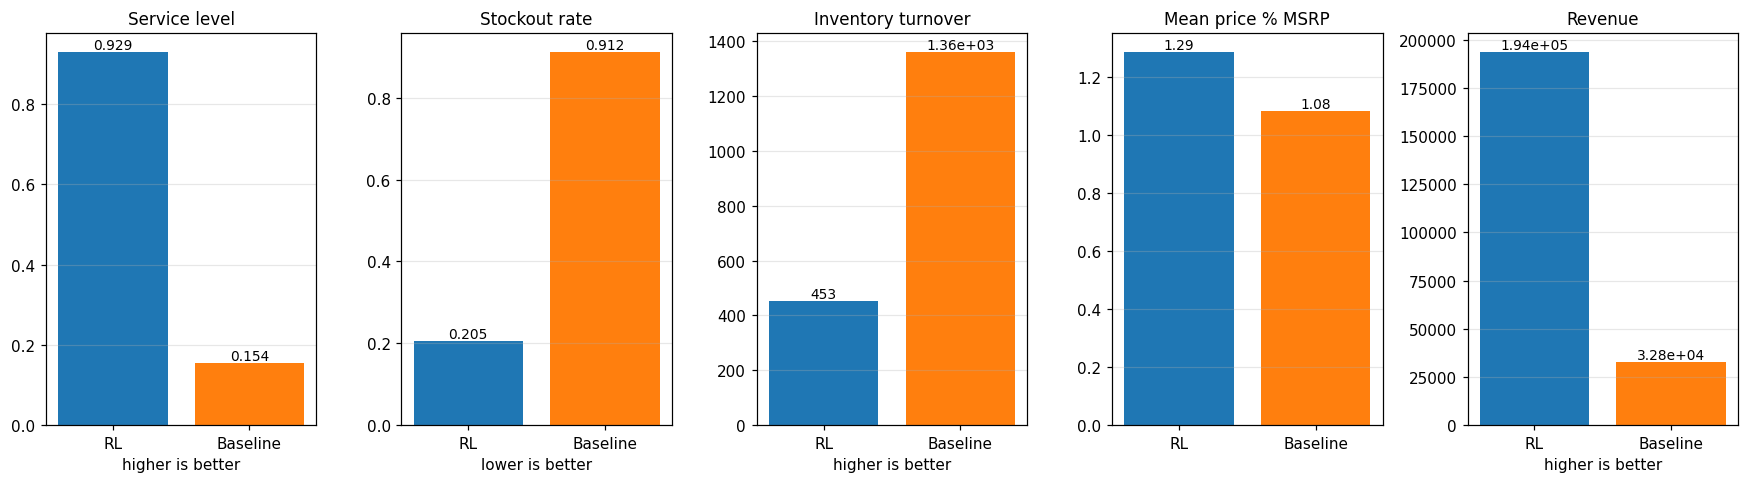

In [11]:
kpis = [
    ('service_level',          'Service level',         True),
    ('stockout_rate',          'Stockout rate',         False),
    ('inventory_turnover',     'Inventory turnover',    True),
    ('mean_price_pct_of_msrp', 'Mean price % MSRP',     None),
    ('revenue',                'Revenue',               True),
]

fig, axes = plt.subplots(1, len(kpis), figsize=(3.2 * len(kpis), 4.5))
for ax, (key, label, higher_better) in zip(axes, kpis):
    rl_val = per_seed[f'rl_{key}'].mean()
    bl_val = per_seed[f'baseline_{key}'].mean()
    bars = ax.bar(['RL', 'Baseline'], [rl_val, bl_val], color=['tab:blue', 'tab:orange'])
    ax.set_title(label, fontsize=11)
    ax.grid(alpha=0.3, axis='y')
    for b, v in zip(bars, [rl_val, bl_val]):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:.3g}',
                ha='center', va='bottom', fontsize=9)
    if higher_better is True:
        ax.set_xlabel('higher is better')
    elif higher_better is False:
        ax.set_xlabel('lower is better')

plt.tight_layout()
plt.show()

## 10. Outliers — best and worst seeds

Where did RL win biggest and where did it lose biggest? The episode parameters (capacity, opening balance, active subset) are exactly the inputs the policy had no control over — they are the regimes where its strategy paid off or failed.

In [12]:
TOP_N = 5
cols = ['seed_idx', 'episode_seed', 'capacity', 'init_balance',
        'baseline_return', 'rl_return', 'uplift',
        'rl_service_level', 'baseline_service_level',
        'rl_stockout_rate', 'baseline_stockout_rate']

top_wins = per_seed.nlargest(TOP_N, 'uplift')[cols].copy()
top_losses = per_seed.nsmallest(TOP_N, 'uplift')[cols].copy()

print(f'Top {TOP_N} seeds where RL won most:')
display = top_wins.set_index('seed_idx')
display

Top 5 seeds where RL won most:


,episode_seed,capacity,init_balance,baseline_return,rl_return,uplift,rl_service_level,baseline_service_level,rl_stockout_rate,baseline_stockout_rate
seed_idx,,,,,,,,,,
26,10000026,196,30450.411298,19472.56,144856.319789,125383.759789,0.921505,0.127808,0.213333,0.935556
30,10000030,232,26899.539881,20694.23,132577.472886,111883.242886,0.934597,0.145936,0.201111,0.923333
17,10000017,172,19588.177257,13309.21,116618.386226,103309.176226,0.886872,0.106015,0.308889,0.958889
22,10000022,174,17209.485608,11976.26,112607.316888,100631.056888,0.930564,0.104685,0.236667,0.948889
8,10000008,317,33181.145616,30291.41,130155.835347,99864.425347,0.955900,0.200638,0.121111,0.882222


In [13]:
print(f'Top {TOP_N} seeds where RL lost most:')
top_losses.set_index('seed_idx')

Top 5 seeds where RL lost most:


,episode_seed,capacity,init_balance,baseline_return,rl_return,uplift,rl_service_level,baseline_service_level,rl_stockout_rate,baseline_stockout_rate
seed_idx,,,,,,,,,,
20,10000020,168,37524.924447,4405.65,41088.022729,36682.372729,0.852671,0.108407,0.387778,0.944444
13,10000013,234,28003.495203,7688.05,48652.914735,40964.864735,0.954379,0.149173,0.165556,0.917778
29,10000029,217,38171.898923,7082.07,52232.539783,45150.469783,0.927393,0.138889,0.237778,0.923333
5,10000005,198,36499.893239,8641.06,57268.502882,48627.442882,0.876944,0.128756,0.324444,0.930000
21,10000021,237,15283.259473,10289.51,58989.608513,48700.098513,0.924775,0.142485,0.243333,0.921111


## 11. Sanity check — uplift vs episode parameters

Quick visual for whether per-seed uplift correlates with capacity or opening balance. A flat cloud is reassuring (policy generalises across the randomisation range); a clear trend means the policy is mostly winning in one regime and losing in another, which is useful to know before deploying.

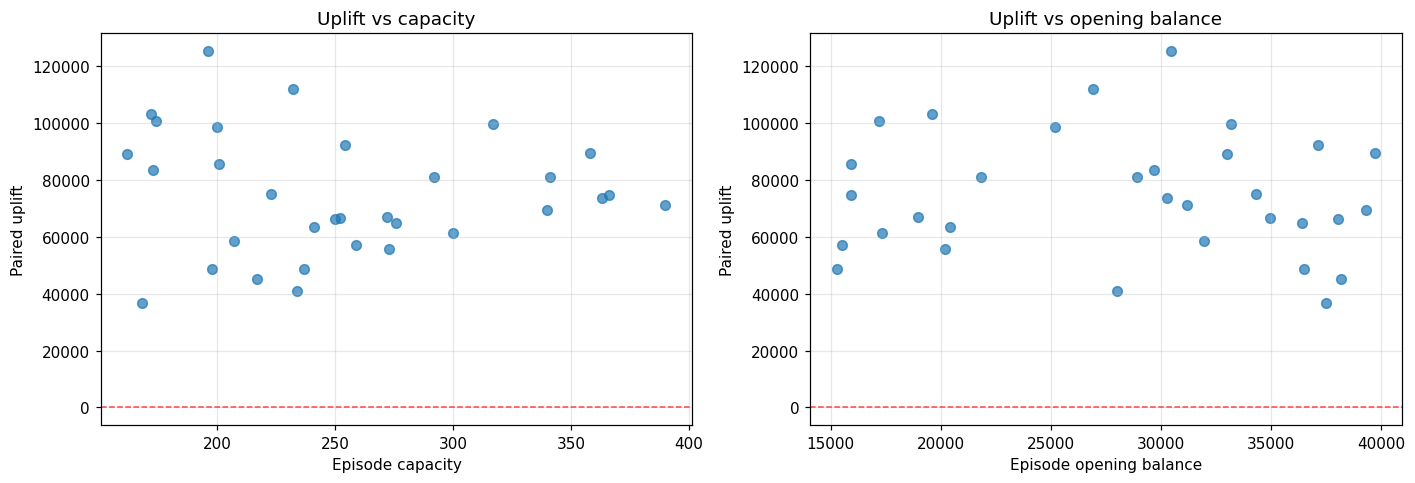

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(per_seed['capacity'], per_seed['uplift'], alpha=0.7, s=40, color='tab:blue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Episode capacity')
axes[0].set_ylabel('Paired uplift')
axes[0].set_title('Uplift vs capacity')
axes[0].grid(alpha=0.3)

axes[1].scatter(per_seed['init_balance'], per_seed['uplift'], alpha=0.7, s=40, color='tab:blue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_xlabel('Episode opening balance')
axes[1].set_ylabel('Paired uplift')
axes[1].set_title('Uplift vs opening balance')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Customising the comparison

**Swap the baseline.** Pass a closure that returns a tuned `BaselinePolicy(...)` — the CRN guarantee still holds because both runs share the same `EpisodeSpec`:

```python
def aggressive_factory():
    return BaselinePolicy(promo_threshold=0.30, promo_discount=0.6)

agg2 = evaluate(rl_policy_fn, aggressive_factory, eval_specs, config=config)
```

**Compare two checkpoints.** Load each into a separate `Actor`, build a closure per actor, and re-run:

```python
actor_a, actor_b = Actor(obs_dim, act_dim), Actor(obs_dim, act_dim)
actor_a.load_state_dict(torch.load(ckpts[0]))
actor_b.load_state_dict(torch.load(ckpts[-1]))
```

**Increase the eval set.** `build_eval_seeds(catalog, base_template, config, n_seeds=128)` extends the held-out range; seeds remain disjoint from training (offset 10 M).